In [946]:
%load_ext autoreload
%autoreload 2

import os, sys, warnings
sys.path.append("/home/jvierstra/proj/vinson")

from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [653]:
import configparser
import pickle

import numpy as np
import pandas as pd
import scipy.stats

from genome_tools.data.anndata import read_zarr_backed

import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec

from matplotlib import rcParams
rcParams["font.sans-serif"] = ["Arial"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    precision_recall_curve, 
    average_precision_score,
)

import torch
from torch.utils.data import DataLoader

import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import (
    Callback,
    EarlyStopping,
    ModelCheckpoint,
)

from vinson.datasets.cell_classifier import EncoderDataset
from vinson.models.cell_classifier import CellAndDiseaseStateClassifierModel

## Prepare training data

In [29]:
nmf_config_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/embeddings/NMF/latest/nmf_config.ini"

config = configparser.ConfigParser()
config.read(nmf_config_file)

['/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/embeddings/NMF/latest/nmf_config.ini']

In [30]:
dnase_adata = read_zarr_backed(config["NMF"]["anndata"])

In [31]:
labels_df = (
    dnase_adata.obs.groupby(["core_annotation", "extended_annotation"])
    .filter(lambda x: len(x) >= 5)[["core_annotation", "extended_annotation", "pathological_state"]]
    .rename(
        columns={
            "core_annotation": "core_annotation",
            "extended_annotation": "extended_annotation",
            "pathological_state": "disease_state",
        }
    )
)

labels_df["cell_category"] = labels_df["core_annotation"].astype(str) + "_" + labels_df["extended_annotation"].astype(str)
labels_df.head()

/tmp/ipykernel_36538/2507374037.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dnase_adata.obs.groupby(["core_annotation", "extended_annotation"])


,core_annotation,extended_annotation,disease_state,cell_category
ag_id,,,,
AG10028,Myeloid,CML,Cancer,Myeloid_CML
AG10029,Myeloid,CML,Cancer,Myeloid_CML
AG10031,Myeloid,CML,Cancer,Myeloid_CML
AG10032,Myeloid,CML,Cancer,Myeloid_CML
AG10033,Myeloid,CML,Cancer,Myeloid_CML


In [32]:
with open(
    "/home/aabisheva/public_html/motif_data/cluster_matrices_unique.pkl", "rb"
) as f:
    data = pickle.load(f)
    human_embedding = data["human_cluster_median"].T
    human_embedding.index.rename("ag_id", inplace=True)
    human_embedding.columns.rename("motif_cluster", inplace=True)

    mouse_embedding = data["mouse_cluster_median"].T
    mouse_embedding.index.rename("ag_id", inplace=True)
    mouse_embedding.columns.rename("motif_cluster", inplace=True)


print(human_embedding.shape)
print(mouse_embedding.shape)


def zscore_normalization(x, eta=1e-5):
    x = np.log(x + eta)
    return (x - x.mean()) / x.std()


human_normed_embedding = human_embedding.apply(zscore_normalization, axis=1)
human_normed_embedding = human_normed_embedding.loc[labels_df.index]

mouse_normed_embedding = mouse_embedding.apply(zscore_normalization, axis=1)

(4159, 637)
(537, 637)


In [33]:
embed_train, embed_valid, labels_train, labels_valid = train_test_split(
    human_normed_embedding,
    labels_df,
    test_size=0.20,
    stratify=labels_df.cell_category,
    random_state=0,
)

In [34]:
encoders = {col: LabelEncoder().fit(labels_df[col]) for col in labels_df.columns}

# Test & validation sets
ds_train = EncoderDataset(embed_train, labels_train, encoders=encoders, noise=0.01)
ds_valid = EncoderDataset(embed_valid, labels_valid, encoders=encoders)

# Eval and select thresholds on the whole dataset
ds_eval =  EncoderDataset(human_normed_embedding, labels_df, encoders=encoders)

# Dataloaders
train_dataloader = DataLoader(ds_train, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(ds_valid, batch_size=32)
eval_dataloader = DataLoader(ds_eval, batch_size=32)

## Train model

In [36]:
model = CellAndDiseaseStateClassifierModel(
    human_normed_embedding.shape[1],
    n_cell_categories=len(encoders["cell_category"].classes_),
    n_disease_states=len(encoders["disease_state"].classes_),
)

In [42]:
model_outdir = "./cell_type_inference/"

try:
    os.mkdir(model_outdir)
except OSError:
        pass

logger = CSVLogger(os.path.join(model_outdir), name="logs")

early_stopping = EarlyStopping(monitor="val_loss", mode="min", min_delta=0.0001, patience=25)
model_checkpoint = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    filename="{epoch}-{step}-{val_loss:.2f}",
    dirpath=os.path.join(
        model_outdir,
        "checkpoints",
    ),
    save_top_k=1,
)

class MetricsCallback(Callback):
    def __init__(self):
        super(MetricsCallback, self).__init__()
        self.train_epoch_loss = []
        self.valid_epoch_loss = []

    def on_validation_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("loss", None)
        valid_loss = trainer.callback_metrics.get("val_loss", None)

        if train_loss:
            self.train_epoch_loss.append(train_loss.item())

        if valid_loss:
            self.valid_epoch_loss.append(valid_loss.item())

train_metrics = MetricsCallback()

callbacks = [
    early_stopping,
    model_checkpoint,
    train_metrics,
]

trainer = L.Trainer(max_epochs=1000, logger=logger, callbacks=callbacks, accelerator="cpu")
trainer.fit(model, train_dataloader, valid_dataloader)

/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type             | Params | Mode 
----------------------------------------------------------------
0 | trunk              | EmbeddingMLP     | 45.2 K | train
1 | head_cell_category | Linear           | 3.4 K  | train
2 | head_disease_state | Linear           | 130    | train
3 | loss_fn            | CrossEntropyLoss | 0      | train
----------------------------------------------------------------
48.8 K    Trainable params
0         Non-trainable params
48.8 K    Total params
0.195     Total e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

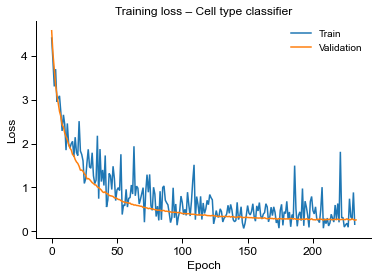

In [603]:
plt.plot(train_metrics.train_epoch_loss, label="Train")
plt.plot(train_metrics.valid_epoch_loss, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training loss – Cell type classifier")

plt.legend()

plt.savefig(os.path.join(model_outdir, "loss_curve.pdf"))

## Evaluate model

In [44]:
model.load_state_dict(torch.load(model_checkpoint.best_model_path)["state_dict"])
#model.load_state_dict(torch.load("lightning_logs/version_29227708/checkpoints/epoch=241-step=24926.ckpt")["state_dict"])

model = model.eval()

In [1209]:
labels_cell_category, labels_disease_state = [], []
p_cell_category, p_disease_state = [], []

with torch.no_grad():
    for batch in eval_dataloader:
        X = batch["embed"]
        y_cell_category = batch["cell_category"]
        y_disease_state = batch["disease_state"]
        _y_cell_category, _y_disease_state = model(X)

        labels_cell_category.append(y_cell_category.cpu().numpy())
        labels_disease_state.append(y_disease_state.cpu().numpy())

        p_cell_category.append(torch.softmax(_y_cell_category, dim=-1).cpu().numpy())
        p_disease_state.append(torch.softmax(_y_disease_state, dim=-1).cpu().numpy())

labels_cell_category = np.concatenate(labels_cell_category)
labels_disease_state = np.concatenate(labels_disease_state)

p_cell_category = np.vstack(p_cell_category)
p_disease_state = np.vstack(p_disease_state)

In [1210]:
core = [x.split("_")[0] for x in encoders["cell_category"].classes_]
extended = [x.split("_")[1] for x in encoders["cell_category"].classes_]

cell_category_columns = pd.MultiIndex.from_arrays([core, extended])

p_extended_annotation = pd.DataFrame(p_cell_category, index=ds_eval.labels.index, columns=cell_category_columns)
labels_extended_annotation_ohe = pd.DataFrame(np.eye(len(encoders["cell_category"].classes_))[labels_cell_category], index=ds_eval.labels.index, columns=cell_category_columns)

p_core_annotation = p_extended_annotation.T.groupby(level=0).sum().T
labels_core_annotation_ohe = labels_extended_annotation_ohe.T.groupby(level=0).max().T

In [1211]:
disease_state_columns = encoders["disease_state"].classes_

p_disease_state = pd.DataFrame(p_disease_state, index=ds_eval.labels.index, columns=disease_state_columns)
labels_disease_state_ohe = pd.DataFrame(np.eye(len(encoders["disease_state"].classes_))[labels_disease_state], index=ds_eval.labels.index, columns=disease_state_columns)


In [1212]:
def get_pr_curves(y_true, y_pred):
    """ Create precision-recall curves """
    pr_curves = []
    
    for cat in y_true.columns:
        precision, recall, thresholds = precision_recall_curve(
            y_true[cat], y_pred[cat]
        )
        thresholds = np.append(thresholds, 1.0)

        if isinstance(cat, str):
            cat = (cat, )
        
        n = len(thresholds)
        levels = tuple([x]* n for x in cat) + (list(range(n)),)
    
        pr_curve = pd.DataFrame(
            {
                "precision": precision,
                "recall": recall,
                "threshold": thresholds,
                "f1": (2 * precision * recall) / (precision + recall + 1e-8),
            },
            index=pd.MultiIndex.from_arrays([l for l in levels]),
        )
        
        pr_curves.append(pr_curve)

    pr_curves = pd.concat(pr_curves)
    
    return pr_curves

def get_classification_thresholds(pr_curves, min_precision=0.95, min_thresh=0.25):
    """ """

    nlevels = pr_curves.index.nlevels
    levels = list(range(nlevels-1))
    
    def compute_thresh(df, min_precision=min_precision, min_thresh=min_thresh):
        subset = df.query("precision >= @min_precision and threshold >=  @min_thresh")
        if subset.empty:
            return 1.0
        else:
            thresh_i = subset["f1"].idxmax()
            return subset["threshold"][thresh_i]

    return pr_curves.groupby(level=levels).apply(compute_thresh)
        

In [1213]:
ap_scores_extended_annotation = average_precision_score(np.argmax(labels_extended_annotation_ohe, axis=1), p_extended_annotation, average=None)
ap_scores_extended_annotation = pd.Series(ap_scores_extended_annotation, index=p_extended_annotation.columns)

ap_scores_core_annotation = average_precision_score(np.argmax(labels_core_annotation_ohe, axis=1), p_core_annotation, average=None)
ap_scores_core_annotation = pd.Series(ap_scores_core_annotation, index=p_core_annotation.columns)


In [1215]:
# Build PR-curves
pr_curves_extended_annotation = get_pr_curves(labels_extended_annotation_ohe, p_extended_annotation)
pr_curves_core_annotation = get_pr_curves(labels_core_annotation_ohe, p_core_annotation)
pr_curves_disease_state = get_pr_curves(labels_disease_state_ohe, p_disease_state)

In [1216]:
thresholds_extended_annotation = get_classification_thresholds(pr_curves_extended_annotation, min_precision=0.95)
thresholds_core_annotation = get_classification_thresholds(pr_curves_core_annotation, min_precision=0.95)
thresholds_disease_state = get_classification_thresholds(pr_curves_disease_state, min_precision=0.99)

(-0.05, 1.0394312911886747)

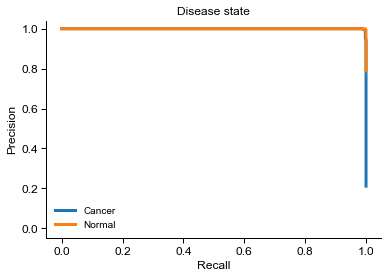

In [1237]:
groups = pr_curves_disease_state.groupby(level=0)
for g, pr_curve in groups:    
    plt.plot(pr_curve.recall, pr_curve.precision, lw=3, label=g)

plt.title("Disease state")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.ylim(bottom=-0.05)

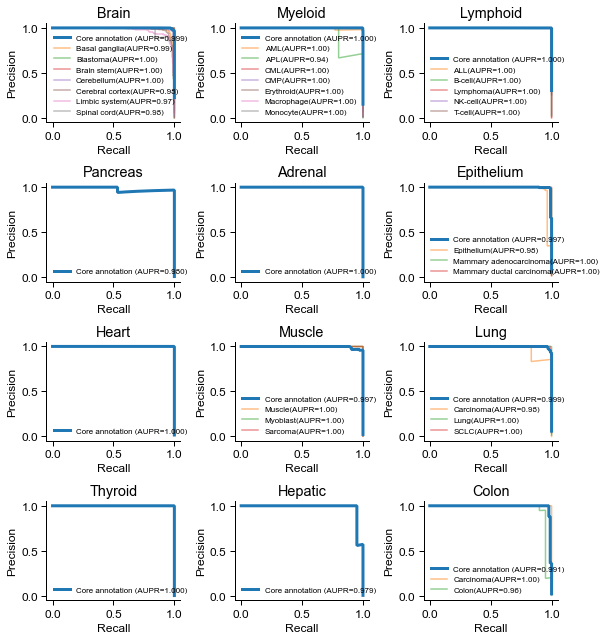

In [1220]:
core_annotation = "Brain"

def plot_pr_for_core_annotation(
    core_annotation, 
    pr_curves_core, 
    pr_curves_extended=None, 
    ap_scores_core=None,
    ap_scores_extended=None,
    ax=None):

    if not ax:
        ax = plt.gca()
        
    pr_curve = pr_curves_core.loc[core_annotation]
    
    label = "Core annotation"
    if ap_scores_core is not None:
        label += f" (AUPR={ap_scores_core.loc[core_annotation]:0.3f})"
        
    ax.plot(pr_curve.recall, pr_curve.precision, lw=3, label=f"{label}")
    
    # thresh = thresholds_core_annotation.loc[core_annotation]
    # thresh_i = pr_curve.index[thresh==pr_curve.threshold]
    
    # pt = (float(pr_curve.recall.iloc[thresh_i]), float(pr_curve.precision.iloc[thresh_i]))
    # plt.scatter(*pt, s=100, color="red", ec="tab:blue", lw=2, zorder=10)
    # plt.annotate(f"Threshold @\n ≥95% precision", xy=pt, xytext=(-6, -4), textcoords="offset fontsize", fontsize="large", arrowprops=dict(arrowstyle="->", shrinkB=10), ha="right", va="center")

    if pr_curves_extended is not None:
        
        groups = pr_curves_extended.loc[core_annotation].groupby(level=0)
        
        if groups.ngroups > 1:       
            for g, pr_curve in groups:
                    
                label = f"{g}"
                if ap_scores_extended is not None:
                    label += f"(AUPR={ap_scores_extended.loc[(core_annotation, g)]:0.2f})"
            
                ax.plot(pr_curve.recall, pr_curve.precision, lw=1.5, alpha=0.5, label=f"{label}", zorder=-1)
            
    ax.legend(prop=dict(size=8), loc=3)
    
    ax.set_title(f"{core_annotation}", fontdict=dict(size="x-large"))
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")

    ax.set_ylim(bottom=-0.05)

core_annotations = [
    "Brain", "Myeloid", "Lymphoid", 
    "Pancreas", "Adrenal", "Epithelium", 
    "Heart", "Muscle", "Lung", 
    "Thyroid", "Hepatic", "Colon"]

nrows = len(core_annotations)// 3 + len(core_annotations)%3

fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(8.5, 9))

for i, core_annotation in enumerate(core_annotations):

    row = i // 3
    col = i % 3
    
    plot_pr_for_core_annotation(
        core_annotation, 
        pr_curves_core_annotation, 
        pr_curves_extended_annotation, 
        ap_score_core_annotation, 
        ap_score_extended_annotation,
        ax=axes[row, col]
    )

fig.tight_layout()

fig.savefig(os.path.join(model_outdir, "pr_curves.pdf"))
            

## Classify public ATAC-seq data

In [1221]:
human_embedding_atac = pd.read_table('/net/seq/data2/projects/aabisheva/DHS_evolution/benchmark/hg38/tf_motif_v23_v2_p1e_minus_5_atac/results/normalized/atac_motif_proportions.tsv').set_index('motif_id')
human_embedding_atac = human_embedding_atac

motif_meta = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/motifs_metadata.annotated.tsv').set_index('motif_id')
human_embedding_atac['motif_cluster'] = motif_meta['unique_cluster_name']

human_embedding_atac = human_embedding_atac.groupby('motif_cluster').agg('median').T
human_normed_embedding_atac = human_embedding_atac.apply(zscore_normalization, axis=1)

assert all(human_normed_embedding_atac.columns == human_normed_embedding.columns), "Column order doesn't match training data!"

In [1222]:
human_normed_embedding_atac.values

def split_batches(x, batch_size=128):
    batches = np.array_split(x, np.arange(batch_size, len(x), batch_size))
    return batches

batches = split_batches(human_normed_embedding_atac.values)

In [1223]:
p_cell_category_atac, p_disease_state_atac = [], []

with torch.no_grad():
    for batch in batches:
        _y_cell_category, _y_disease_state = model(torch.tensor(batch).to(torch.float32))
        p_cell_category_atac.append(torch.softmax(_y_cell_category, dim=-1).cpu().numpy())
        p_disease_state_atac.append(torch.softmax(_y_disease_state, dim=-1).cpu().numpy())

p_cell_category_atac = np.vstack(p_cell_category_atac)
p_disease_state_atac = np.vstack(p_disease_state_atac)

p_extended_annotation_atac = pd.DataFrame(p_cell_category_atac, index=human_normed_embedding_atac.index, columns=cell_category_columns)
p_core_annotation_atac = p_extended_annotation_atac.T.groupby(level=0).sum().T
p_disease_state_atac = pd.DataFrame(p_disease_state_atac, index=human_normed_embedding_atac.index, columns=disease_state_columns)

In [1224]:
preds_extended_annotation_atac = p_extended_annotation_atac.apply(lambda x: x>=thresholds_extended_annotation[x.name])
preds_core_annotation_atac = p_core_annotation_atac.apply(lambda x: x>=thresholds_core_annotation[x.name])
preds_disease_state_atac = p_disease_state_atac.apply(lambda x: x>=thresholds_disease_state[x.name])

In [1225]:
print(f"Number of normal: {preds_disease_state_atac['Normal'].sum()}")
print(f"Number of cancer: {preds_disease_state_atac['Cancer'].sum()}")

Number of normal: 6879
Number of cancer: 3682


In [1226]:
def filter_fn(x):
    filtered_indices = x.index[x>0]
    if isinstance(x.index, pd.MultiIndex):
        if filtered_indices.empty:
            values = [pd.NA for _ in range(x.index.nlevels)]
        else:
            values = [filtered_indices[0][i] for i in range(x.index.nlevels)]
        return pd.Series(values)
    else:
        if filtered_indices.empty:
            return pd.NA
        else:
            return filtered_indices[0]

inferred_core_annotation_atac = preds_core_annotation_atac.apply(filter_fn, axis=1)
inferred_extended_annotation_atac = preds_extended_annotation_atac.apply(filter_fn, axis=1)
inferred_disease_state_atac = preds_disease_state_atac.apply(filter_fn, axis=1)

In [1227]:
sra_preds = pd.concat(
    [inferred_core_annotation_atac, 
     inferred_extended_annotation_atac, 
     inferred_disease_state_atac], axis=1)

sra_preds.columns = ["core_annotation", "_", "extended_annotation", "disease_state"]
sra_preds.index.name = "sra_id"

def resolve_core_annotation(x):
    if not pd.isna(x["_"]):
        x["core_annotation"] = x["_"]
    return x

sra_preds = sra_preds.apply(resolve_core_annotation, axis=1)

In [1228]:
has_extended_annotation = preds_extended_annotation_atac.sum(axis=1) > 0
has_core_annotation = preds_core_annotation_atac.sum(axis=1) > 0

samples_to_refine = has_core_annotation

refined = []
for idx, core in inferred_core_annotation_atac[samples_to_refine].items():
    row = p_extended_annotation_atac.loc[idx, core].sort_values(ascending=False)
    i = np.where((row.cumsum()/row.sum()).values > 0.95)[0][0]+1

    ret = ""
    for k, v in row.iloc[:i].items():
       ret += f"{k}={v:0.2f},"
    refined.append((idx, ret[:-1]))


refined = pd.DataFrame(refined).rename(
    columns={
        0: "sra_id", 
        1: "ranked_extended_annotations"
    }).set_index("sra_id")


In [1229]:
sra_preds = sra_preds.join(refined).drop("_", axis=1)
sra_preds.to_csv(os.path.join(model_outdir, "sra_atac_annotations.tsv"), index=True, header=True, sep="\t")

In [1230]:
sra_preds.groupby("core_annotation").size().sum()

8135

In [1233]:
sra_preds[sra_preds.ranked_extended_annotations.str.contains("^Epith", na=False)].head(n=20)

,core_annotation,extended_annotation,disease_state,ranked_extended_annotations
sra_id,,,,
DRX130237,Epithelium,Epithelium,Normal,Epithelium=0.82
DRX130290,Epithelium,Epithelium,Cancer,"Epithelium=0.40,Mammary adenocarcinoma=0.10"
ERX4064326,Epithelium,Epithelium,Normal,Epithelium=0.86
SRX10056606,Epithelium,Epithelium,Normal,Epithelium=0.44
SRX10128641,Epithelium,Epithelium,Cancer,Epithelium=0.48
SRX10142220,Epithelium,Epithelium,Normal,Epithelium=0.98
SRX10142221,Epithelium,Epithelium,Normal,Epithelium=0.98
SRX10475783,Epithelium,Epithelium,Normal,Epithelium=0.99
SRX10475784,Epithelium,Epithelium,Normal,Epithelium=0.99


In [1232]:
sra_preds.groupby(["core_annotation", "extended_annotation"]).size()

core_annotation                  extended_annotation            
Adrenal                          Adrenal                              14
Brain                            Basal ganglia                       131
                                 Cerebellum                            2
                                 Cerebral cortex                      22
                                 Limbic system                        29
                                 Spinal cord                           4
Colon                            Carcinoma                           159
                                 Colon                                21
Endothelium                      Endothelium                         141
Epithelium                       Epithelium                          527
                                 Mammary adenocarcinoma              250
                                 Mammary ductal carcinoma             98
Eye                              Eye                       

## Attributions per annotation

In [1200]:
class Wrapper(torch.nn.Module):
    def __init__(self, model):
        super(Wrapper, self).__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)[0]

wrapper_model = Wrapper(model)
wrapper_model = wrapper_model.eval()

# Baslines generator
embedding_len = human_normed_embedding.shape[1]
embedding_mu = human_normed_embedding.median(axis=0)
embedding_mad = scipy.stats.median_abs_deviation(human_normed_embedding, axis=0)

generate_baselines = lambda x: torch.tensor(np.random.normal(loc=mu, scale=mad, size=(100, embedding_len))).to(torch.float32)

In [1201]:
explainer = DeepLiftShap(wrapper_model, multiply_by_inputs=True)

attrs = {}

for core, extended in labels_extended_annotation_ohe.columns:
    target = encoders["cell_category"].transform([f"{core}_{extended}"])[0]
    samples = labels_extended_annotation_ohe.index[labels_extended_annotation_ohe.idxmax(axis=1) == (core, extended)]

    X = torch.tensor(human_normed_embedding.loc[samples].values).to(torch.float32)
    # baselines = np.random.normal(loc=mu, scale=mad, size=(50, embedding_len))
    
    with warnings.catch_warnings():
        
        warnings.simplefilter("ignore", category=UserWarning)

        attr = explainer.attribute(X, baselines=generate_baselines, target=int(target)).detach().numpy()

    for i, sample in enumerate(samples):
        attrs[(core, extended, sample)] = attr[i]

attrs = pd.DataFrame(attrs, index=human_normed_embedding.columns).T

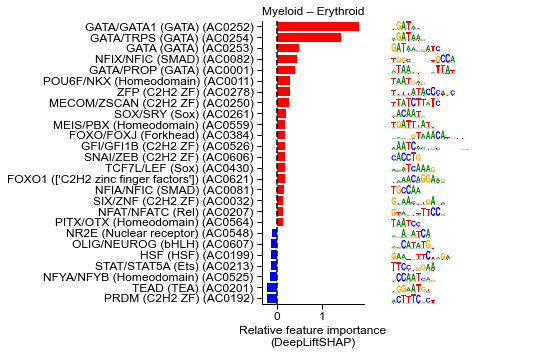

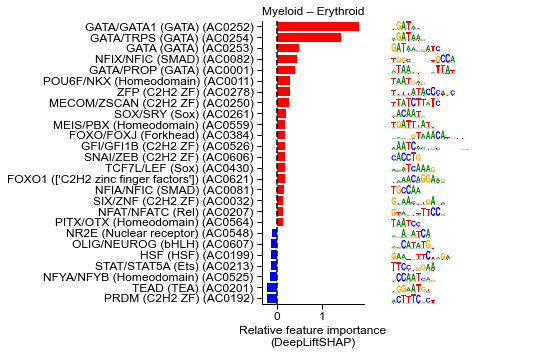

In [1202]:
motif_metadata = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/motifs_metadata.annotated.tsv')

def plot_attributions(
    attribs,
    motif_metadata, 
    pfm_base_path="/home/jvierstra/public_html/projects/motif-clustering-v2.1beta/pfms/clusters",
    name=None,
    fig=None):
    """ """
    loc, scale = scipy.stats.laplace.fit(attribs[attribs<0.5], loc=0)
   
    p_upper = scipy.stats.laplace.sf(attribs, loc=loc, scale=scale)
    p_lower = scipy.stats.laplace.cdf(attribs, loc=loc, scale=scale)
    p = np.min(np.vstack([p_upper, p_lower]), axis=0) * 2

    df = pd.DataFrame({"attribution": attribs, "p": p}).sort_values(by="attribution")
    df = df.query("p < 0.01")

    motifs = motif_metadata.groupby("unique_cluster_name").first().loc[df.index][["cluster", "family_name", "cluster_name"]]
    bar_labels = motifs["cluster_name"] + " (" + motifs["family_name"] + ")" + " (" + motifs["cluster"] + ")"

    if not fig:
        fig = plt.figure()
        
    gs = mgridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 3])

    ax = plt.subplot(gs[0,0])

    bar_color = np.where(df.attribution>0, "red", "blue")
    p = ax.barh(bar_labels, df.attribution, color=bar_color)
    
    ax.axvline(0, color="k", ls='--')
    
    ax.set_xlabel("Relative feature importance\n(DeepLiftSHAP)")
    ax.set_ylim(bottom=-0.5, top=len(df)-0.5)

    if name:
        ax.set_title(name)
    
    subplot_spec = mgridspec.GridSpecFromSubplotSpec(len(df), 1, subplot_spec=gs[0, 1])    
    for i, motif_cluster in enumerate(df.index[::-1]):
        ax = plt.subplot(subplot_spec[i,0])
        pfm = np.loadtxt(os.path.join(pfm_base_path, f"{motifs['cluster'].loc[motif_cluster]}.pfm"))
        plot_logo(compute_ic(pfm), ax=ax)
        ax.set_xlim(-1, 30)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)

    # fig.tight_layout()
    fig.set_size_inches(5, len(df)*0.2)
    return fig


plot_attributions(attrs.loc[("Myeloid", "Erythroid")].mean(axis=0), motif_metadata, name="Myeloid – Erythroid", fig=plt.figure())


In [974]:
%%capture

for index in tqdm(labels_extended_annotation_ohe.columns):
    X = attrs.loc[index]
    name = f"{'_'.join(index)}"

    filename = name
    for char in ["/", "-", " "]:
        filename = filename.replace(char, '_')
                                                                    
    fig = plt.figure()
    fig = plot_attributions(X.mean(axis=0), motif_metadata, fig=fig, name=name.replace("_", " – "))
    fig.savefig(os.path.join(model_outdir, f"attribution_{filename}.pdf"))

## Classify mouse data

In [1203]:
mouse_metadata = pd.read_table("/net/seq/data2/projects/acote/projects/encode4/hs3_index/metadata/mouse/mouse_metadata_250820JVsysupdate.tsv", index_col=0)

cols = cell_category_columns.get_level_values(0).isin(mouse_metadata.core_annotation)

mouse_metadata = mouse_metadata[mouse_metadata.core_annotation.isin(cell_category_columns.get_level_values(0)[cols])]


In [1204]:
with torch.no_grad():
    X = torch.tensor(mouse_normed_embedding.loc[mouse_metadata.index].values).to(torch.float32)
    _y_cell_category, _y_disease_state = model(X)
    p_cell_category_mouse = torch.softmax(_y_cell_category, dim=-1).cpu().numpy()
    p_disease_state_mouse = torch.softmax(_y_disease_state, dim=-1).cpu().numpy()

p_extended_annotation_mouse = pd.DataFrame(p_cell_category_mouse[:,cols], index=mouse_metadata.index, columns=cell_category_columns[cols])
p_core_annotation_mouse = p_extended_annotation_mouse.T.groupby(level=0).sum().T


In [1205]:
labels_core_annotation_mouse = [p_core_annotation_mouse.columns.get_loc(x) for x in mouse_metadata.core_annotation]
labels_core_annotation_mouse_ohe = pd.DataFrame(np.eye(p_core_annotation_mouse.shape[1])[labels_core_annotation_mouse], index=mouse_metadata.index, columns=p_core_annotation_mouse.columns)

In [1206]:
pr_curves_core_annotation_mouse = get_pr_curves(labels_core_annotation_mouse_ohe, p_core_annotation_mouse)

ap_scores_core_annotation_mouse = average_precision_score(np.argmax(labels_core_annotation_mouse_ohe, axis=1), p_core_annotation_mouse, average=None)
ap_scores_core_annotation_mouse = pd.Series(ap_scores_core_annotation_mouse, index=p_core_annotation_mouse.columns)


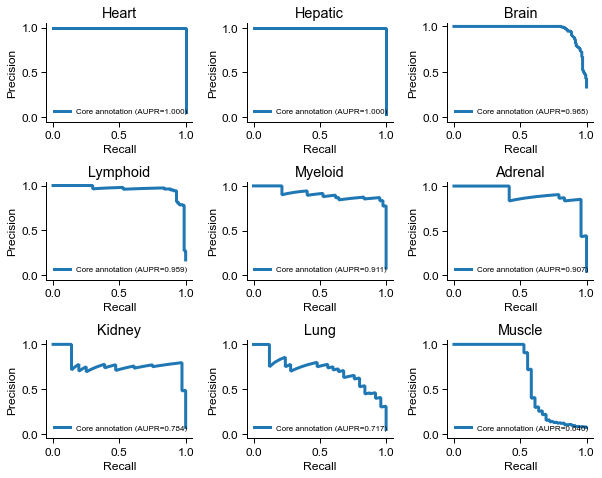

In [1234]:
core_annotations = [
    "Brain", "Myeloid", "Lymphoid", 
    "Adrenal", "Heart", "Muscle", "Lung", 
    "Kidney", "Hepatic"]

ap = {
    a: ap_scores_core_annotation_mouse[a] for a in core_annotations
}

nrows = len(core_annotations)//3 + len(core_annotations)%3

fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(8.5, 6.75))

for i, (k, _) in enumerate(sorted(ap.items(), key=lambda x: x[1])[::-1]):

    row = i // 3
    col = i % 3
    
    plot_pr_for_core_annotation(
        k, 
        pr_curves_core_annotation_mouse,
        ap_scores_core=ap_scores_core_annotation_mouse,
        ax=axes[row, col]
    )

fig.tight_layout()

fig.savefig(os.path.join(model_outdir, "pr_curves_mouse.pdf"))
            